In [23]:
print("Bins favoring Glioblastoma")
display(top_positive[["bin_id", "region", "coefficient"]])

print("Bins favoring Ovarian high-grade serous adenocarcinoma")
display(top_negative[["bin_id", "region", "coefficient"]])


Bins favoring Glioblastoma


,bin_id,region,coefficient
0,chr7_10000000_20000000,chr7:10-20 Mb,0.307023
1,chr7_20000000_30000000,chr7:20-30 Mb,0.296866
2,chr4_40000000_50000000,chr4:40-50 Mb,0.279799
3,chr18_60000000_70000000,chr18:60-70 Mb,0.261521
4,chr4_80000000_90000000,chr4:80-90 Mb,0.237993
5,chr7_50000000_60000000,chr7:50-60 Mb,0.236378
6,chr18_50000000_60000000,chr18:50-60 Mb,0.232615
7,chr8_0_10000000,chr8:0-10 Mb,0.228835
8,chr4_50000000_60000000,chr4:50-60 Mb,0.220071
9,chr3_20000000_30000000,chr3:20-30 Mb,0.219368


Bins favoring Ovarian high-grade serous adenocarcinoma


,bin_id,region,coefficient
0,chr8_130000000_140000000,chr8:130-140 Mb,-0.346343
1,chr1_130000000_140000000,chr1:130-140 Mb,-0.337152
2,chr20_60000000_64444167,chr20:60-64 Mb,-0.323382
3,chr1_120000000_130000000,chr1:120-130 Mb,-0.306586
4,chr12_10000000_20000000,chr12:10-20 Mb,-0.303045
5,chr22_30000000_40000000,chr22:30-40 Mb,-0.269249
6,chr4_190000000_190214555,chr4:190-190 Mb,-0.255717
7,chr8_140000000_145138636,chr8:140-145 Mb,-0.255582
8,chr15_80000000_90000000,chr15:80-90 Mb,-0.225992
9,chr20_50000000_60000000,chr20:50-60 Mb,-0.225137


In [24]:
# pick 1 bin: glioblastoma (top_positive) because the coefficient is positive 
#i chose the 1st (position 0 bin of the glioblastoma): 0	chr7_10000000_20000000	chr7:10-20 Mb	0.311080
bin_id = top_positive["bin_id"].iloc[0]
coefs[bin_id]

np.float64(0.307023254502708)

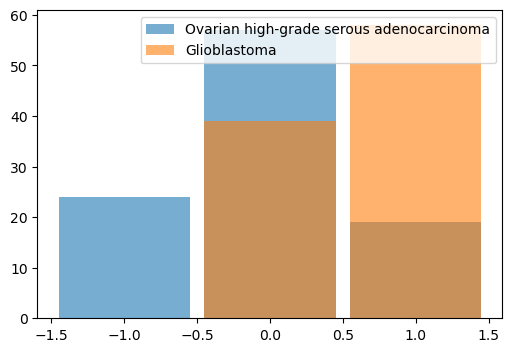

In [25]:
#inspect the histogram
bin_id = top_positive["bin_id"].iloc[0]  # or top_negative

plt.figure(figsize=(6, 4))

for group_code in [GROUP_1, GROUP_2]:
    values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
    plt.hist(
        values,
        bins=[-1.5, -0.5, 0.5, 1.5],
        alpha=0.6,
        label=GROUP_LABELS[group_code],
        rwidth=0.9,
    )

plt.legend()
plt.show()

#we can see that this bin is most likely associated with duplications in glioblastoma 

Using the Progenetix collation plot link, I deduced that the findings matched. It showed duplication events in chromosome 7 (shown by the higher yellow lines at chr7). This is backed up by the histogram which shows that the bin (in chr7) is associated with duplications in glioblastoma. 

In [ ]:
# Everything from here on out is not the answer but just a copy of the exercise
import json
import math
import time
from collections import defaultdict

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Progress bars for slow download steps
from tqdm.auto import tqdm

# HTTP requests to the Progenetix Beacon API
import requests

# scikit-learn tools for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Notebook display helper
from IPython.display import display


In [6]:
GROUP_1 = "NCIT:C105555"
GROUP_2 = "NCIT:C3058"

GROUP_LABELS = {
    GROUP_1: "Ovarian high-grade serous adenocarcinoma",
    GROUP_2: "Glioblastoma",
}

TARGET_SAMPLES_PER_CLASS = 100

# We use coarse 10 Mb bins.
# Larger bins are easier to explain and produce a smaller feature table.
BIN_SIZE = 10_000_000

# RANDOM_STATE makes the random sampling reproducible.
RANDOM_STATE = 42

# Timeout for web requests, in seconds.
TIMEOUT = 300

print("Groups:")
for g in [GROUP_1, GROUP_2]:
    print(f"  {g}: {GROUP_LABELS[g]}")
print()
print("TARGET_SAMPLES_PER_CLASS =", TARGET_SAMPLES_PER_CLASS)
print("BIN_SIZE =", BIN_SIZE)


Groups:
  NCIT:C105555: Ovarian high-grade serous adenocarcinoma
  NCIT:C3058: Glioblastoma

TARGET_SAMPLES_PER_CLASS = 100
BIN_SIZE = 10000000


In [7]:
def extract_results_from_beacon_json(data):
    # Return the main list of result records from a Beacon JSON response.
    response = data.get("response", {})
    results = response.get("results")
    if results is not None:
        return results

    result_sets = response.get("resultSets", [])
    if result_sets:
        return result_sets[0].get("results", [])

    return []


def fetch_analysis_candidates(group_code, limit=120):
    """Download candidate analyses for one diagnostic group.

    We query analyses because an analysis represents a sample with a specific
    bioinformatics result set attached to it.
    """
    params = {
        "datasetIds": "progenetix",
        "filters": group_code,
        "analysis_operation.id": "EDAM:operation_3961",  # copy-number variation detection
        "limit": limit,
        "skip": 0,
        "requestedGranularity": "record",
    }

    r = SESSION.get(ANALYSES_URL, params=params, timeout=TIMEOUT)
    r.raise_for_status()

    results = extract_results_from_beacon_json(r.json())

    rows = []
    for item in results:
        rows.append({
            "analysis_id": item.get("id"),
            "biosample_id": item.get("biosampleId") or item.get("biosample_id"),
            "individual_id": item.get("individualId") or item.get("individual_id"),
            "group_code": group_code,
            "group_label": GROUP_LABELS[group_code],
            "analysis_label": item.get("label"),
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        # Keep only rows with the minimum identifiers we need later.
        df = df.dropna(subset=["analysis_id", "biosample_id"]).copy()

        # keep one row per biosample.
        # This reduces the chance that the same biosample appears twice.
        df = df.drop_duplicates(subset=["biosample_id"]).copy()

    return df


def fetch_variants_for_biosample(biosample_id):
    # Download all variant records for one biosample.
    url = f"{BIOSAMPLES_BASE_URL}{biosample_id}/g_variants/"
    r = SESSION.get(url, timeout=TIMEOUT)
    r.raise_for_status()
    return r.json(), r.url


def classify_copy_change(variation):
    # Map detailed CNV labels to a simple DEL / DUP / OTHER coding.
    label = (
        (variation.get("variantState", {}) or {}).get("label")
        or variation.get("copyChange", "")
    )

    if not isinstance(label, str):
        return "OTHER"

    label = label.lower()

    if "loss" in label or "deletion" in label:
        return "DEL"
    if "gain" in label or "amplification" in label or "dup" in label:
        return "DUP"
    return "OTHER"


def variant_records_to_segments(results, group_code, allowed_analysis_ids=None):
    # Convert Beacon genomic-variation records into a simple segment table.
    rows = []

    for item in results:
        variation = item.get("variation", {}) or {}
        location = variation.get("location", {}) or {}
        case_level_data = item.get("caseLevelData", []) or []

        chromosome = location.get("chromosome")
        start = location.get("start")
        end = location.get("end")
        variant_type = classify_copy_change(variation)

        # We keep only simple duplication / deletion style events.
        if variant_type not in {"DEL", "DUP"}:
            continue
        if chromosome is None or start is None or end is None:
            continue

        for case in case_level_data:
            analysis_id = case.get("analysisId")
            biosample_id = case.get("biosampleId")
            individual_id = case.get("individualId")

            # Some variant records may mention multiple analyses.
            # We keep only the analyses we intentionally selected.
            if allowed_analysis_ids is not None and analysis_id not in allowed_analysis_ids:
                continue

            rows.append({
                "analysis_id": analysis_id,
                "biosample_id": biosample_id,
                "individual_id": individual_id,
                "chromosome": str(chromosome).replace("chr", ""),
                "start": int(start),
                "end": int(end),
                "variant_type": variant_type,
                "group_code": group_code,
            })

    return pd.DataFrame(rows)


def clean_segments(seg_df):
    """Basic cleaning for the segment table."""
    if seg_df.empty:
        return seg_df.copy()

    df = seg_df.copy()
    df["chromosome"] = df["chromosome"].astype(str)

    # Keep only autosomes 
    valid_chromosomes = {str(i) for i in range(1, 23)}
    df = df[df["chromosome"].isin(valid_chromosomes)].copy()

    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["analysis_id", "biosample_id", "chromosome", "start", "end", "variant_type"])
    df = df[df["end"] > df["start"]].copy()

    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)

    return df


In [8]:
ANALYSES_URL = "https://progenetix.org/beacon/analyses/"
BIOSAMPLES_BASE_URL = "https://progenetix.org/beacon/biosamples/"

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})


In [9]:
group1_candidates = fetch_analysis_candidates(GROUP_1, limit=200)
group2_candidates = fetch_analysis_candidates(GROUP_2, limit=200)

print("Candidate biosamples")
print("--------------------")
print(GROUP_LABELS[GROUP_1], ":", len(group1_candidates))
print(GROUP_LABELS[GROUP_2], ":", len(group2_candidates))

display(group1_candidates.head())
display(group2_candidates.head())

# Quick duplication check
print("\nDuplicate biosample IDs")
print("-----------------------")
print("Group 1:", group1_candidates["biosample_id"].duplicated().sum())
print("Group 2:", group2_candidates["biosample_id"].duplicated().sum())


Candidate biosamples
--------------------
Ovarian high-grade serous adenocarcinoma : 200
Glioblastoma : 200


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftwtx4p,pgxbs-kftvks8q,pgxind-kftx6xzq,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
1,pgxcs-kftwtyba,pgxbs-kftvkscg,pgxind-kftx6y4c,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
2,pgxcs-kftwtybs,pgxbs-kftvksch,pgxind-kftx6y4f,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
3,pgxcs-kftwtypy,pgxbs-kftvksdt,pgxind-kftx6y62,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
4,pgxcs-kftwtyys,pgxbs-kftvksem,pgxind-kftx6y73,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftvgl5h,pgxbs-kftvgl5h,pgxind-kftx2bqc,NCIT:C3058,Glioblastoma,Glioblastoma
1,pgxcs-kftvlijb,pgxbs-kftva5zv,pgxind-kftx266l,NCIT:C3058,Glioblastoma,glioblastoma
2,pgxcs-kftvlijs,pgxbs-kftva5zw,pgxind-kftx266n,NCIT:C3058,Glioblastoma,glioblastoma
3,pgxcs-kftvlika,pgxbs-kftva5zy,pgxind-kftx266p,NCIT:C3058,Glioblastoma,glioblastoma
4,pgxcs-kftvlikr,pgxbs-kftva5zz,pgxind-kftx266r,NCIT:C3058,Glioblastoma,glioblastoma



Duplicate biosample IDs
-----------------------
Group 1: 0
Group 2: 0


In [10]:
n_per_class = min(TARGET_SAMPLES_PER_CLASS, len(group1_candidates), len(group2_candidates))

group1_selected = group1_candidates.sample(n=n_per_class, random_state=RANDOM_STATE).reset_index(drop=True)
group2_selected = group2_candidates.sample(n=n_per_class, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Selected {n_per_class} biosamples per class")

display(group1_selected.head())
display(group2_selected.head())


Selected 100 biosamples per class


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
1,pgxcs-kftwu724,pgxbs-kftvkt3w,pgxind-kftx6z2p,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,pgxind-kftx73t3,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,pgxind-kftx7ire,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,pgxind-kftx7ej6,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftvmmgq,pgxbs-kftvgk9v,pgxind-kftx2anx,NCIT:C3058,Glioblastoma,Glioblastoma
1,pgxcs-kftvlqwg,pgxbs-kftvghcn,pgxind-kftx273v,NCIT:C3058,Glioblastoma,Glioblastoma [familial]
2,pgxcs-kftvm0b3,pgxbs-kftvgi86,pgxind-kftx2865,NCIT:C3058,Glioblastoma,gliosarcoma [sarcoma component]
3,pgxcs-kftvmnbj,pgxbs-kftvgkcw,pgxind-kftx2arn,NCIT:C3058,Glioblastoma,Glioblastoma
4,pgxcs-kftvmmxj,pgxbs-kftvgkbi,pgxind-kftx2apz,NCIT:C3058,Glioblastoma,Glioblastoma


In [11]:
def fetch_variation_segments_for_selected_biosamples(group_code, selected_df):
    # Download and clean CNV events for one selected group.
    all_segments = []
    matched = []
    failures = []

    biosample_ids = selected_df["biosample_id"].dropna().astype(str).tolist()
    allowed_analysis_ids = set(selected_df["analysis_id"].dropna().astype(str).tolist())

    pbar = tqdm(biosample_ids, desc=f"Fetching variants for {GROUP_LABELS[group_code]}")

    for biosample_id in pbar:
        try:
            data, final_url = fetch_variants_for_biosample(biosample_id)
            results = extract_results_from_beacon_json(data)

            seg_df = variant_records_to_segments(
                results,
                group_code=group_code,
                allowed_analysis_ids=allowed_analysis_ids,
            )
            seg_df = clean_segments(seg_df)

            if seg_df.empty:
                failures.append((biosample_id, "no CNV rows after filtering"))
            else:
                seg_df["source_url"] = final_url
                all_segments.append(seg_df)
                matched.append(biosample_id)

        except Exception as e:
            failures.append((biosample_id, f"{type(e).__name__}: {e}"))

        pbar.set_postfix(success=len(matched), fail=len(failures))

    combined = pd.concat(all_segments, ignore_index=True) if all_segments else pd.DataFrame()
    return combined, matched, failures


In [12]:
group1_segments, group1_matched, group1_failures = fetch_variation_segments_for_selected_biosamples(
    GROUP_1, group1_selected
)
group2_segments, group2_matched, group2_failures = fetch_variation_segments_for_selected_biosamples(
    GROUP_2, group2_selected
)

print("Matched biosamples with at least one CNV event")
print("----------------------------------------------")
print(GROUP_LABELS[GROUP_1], ":", len(group1_matched))
print(GROUP_LABELS[GROUP_2], ":", len(group2_matched))

print("\nExample failures")
print("Group 1:", group1_failures[:3])
print("Group 2:", group2_failures[:3])

Fetching variants for Ovarian high-grade serous adenocarcinoma:   0%|          | 0/100 [00:00<?, ?it/s]

Fetching variants for Glioblastoma:   0%|          | 0/100 [00:00<?, ?it/s]

Matched biosamples with at least one CNV event
----------------------------------------------
Ovarian high-grade serous adenocarcinoma : 100
Glioblastoma : 97

Example failures
Group 1: []
Group 2: [('pgxbs-kftvgi84', 'no CNV rows after filtering'), ('pgxbs-kftvgi7z', 'no CNV rows after filtering'), ('pgxbs-kftvgi8b', 'no CNV rows after filtering')]


In [13]:
segments = pd.concat([group1_segments, group2_segments], ignore_index=True)

print("Combined CNV segments:", len(segments))
display(segments.head())

sample_counts = (
    segments[["analysis_id", "group_code"]]
    .drop_duplicates()
    .groupby("group_code")
    .size()
    .rename("n_samples")
    .reset_index()
)
sample_counts["group_label"] = sample_counts["group_code"].map(GROUP_LABELS)
display(sample_counts)

print("Duplicate analysis IDs in segment metadata:", segments[["analysis_id"]].drop_duplicates()["analysis_id"].duplicated().sum())


Combined CNV segments: 20683


,analysis_id,biosample_id,individual_id,chromosome,start,end,variant_type,group_code,source_url
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,2,239756508,241858801,DEL,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
1,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,9,136544063,136672275,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
2,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,5,218387,256377,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
3,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,20,365220,61851057,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
4,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,17,39699574,39727867,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...


,group_code,n_samples,group_label
0,NCIT:C105555,100,Ovarian high-grade serous adenocarcinoma
1,NCIT:C3058,97,Glioblastoma


Duplicate analysis IDs in segment metadata: 0


In [15]:
# Approximate GRCh38 chromosome lengths for autosomes.
# We only need these lengths to create coarse 10Mb bins.
CHROM_LENGTHS = {
    "1": 248_956_422,
    "2": 242_193_529,
    "3": 198_295_559,
    "4": 190_214_555,
    "5": 181_538_259,
    "6": 170_805_979,
    "7": 159_345_973,
    "8": 145_138_636,
    "9": 138_394_717,
    "10": 133_797_422,
    "11": 135_086_622,
    "12": 133_275_309,
    "13": 114_364_328,
    "14": 107_043_718,
    "15": 101_991_189,
    "16": 90_338_345,
    "17": 83_257_441,
    "18": 80_373_285,
    "19": 58_617_616,
    "20": 64_444_167,
    "21": 46_709_983,
    "22": 50_818_468,
}

bin_rows = []
for chrom, chrom_len in CHROM_LENGTHS.items():
    n_bins = math.ceil(chrom_len / BIN_SIZE)
    for i in range(n_bins):
        start = i * BIN_SIZE
        end = min((i + 1) * BIN_SIZE, chrom_len)
        bin_rows.append({
            "chromosome": chrom,
            "bin_id": f"chr{chrom}_{start}_{end}",
            "bin_start": start,
            "bin_end": end,
        })

bin_df = pd.DataFrame(bin_rows)
print("Number of genome bins:", len(bin_df))
display(bin_df.head())


Number of genome bins: 300


,chromosome,bin_id,bin_start,bin_end
0,1,chr1_0_10000000,0,10000000
1,1,chr1_10000000_20000000,10000000,20000000
2,1,chr1_20000000_30000000,20000000,30000000
3,1,chr1_30000000_40000000,30000000,40000000
4,1,chr1_40000000_50000000,40000000,50000000


In [16]:
def bin_segments_to_matrix(seg_df, bin_df):
     # Turn a long CNV segment table into a sample-by-feature matrix.
    if seg_df.empty:
        return pd.DataFrame()

    # Keep sample identifiers once per sample.
    sample_meta = (
        seg_df[["analysis_id", "biosample_id", "group_code"]]
        .drop_duplicates()
        .copy()
    )

    bin_ids = bin_df["bin_id"].tolist()

    # Start with a matrix of zeros:
    # rows = samples, columns = genome bins
    X = pd.DataFrame(
        0,
        index=sample_meta["analysis_id"].tolist(),
        columns=bin_ids,
        dtype=np.int8
    )

    # Group bins by chromosome so that overlap checking is faster.
    bins_by_chr = {
        chrom: subdf[["bin_start", "bin_end", "bin_id"]].copy()
        for chrom, subdf in bin_df.groupby("chromosome")
    }

    # Go through each CNV event and mark all overlapping bins.
    for row in tqdm(seg_df.itertuples(index=False), total=len(seg_df), desc="Binning CNV events"):
        chrom = row.chromosome
        if chrom not in bins_by_chr:
            continue

        bins_chr = bins_by_chr[chrom]
        overlaps = bins_chr[
            (bins_chr["bin_start"] < row.end) &
            (bins_chr["bin_end"] > row.start)
        ]["bin_id"].tolist()

        if not overlaps:
            continue

        value = -1 if row.variant_type == "DEL" else 1
        X.loc[row.analysis_id, overlaps] = value

    X = X.reset_index().rename(columns={"index": "analysis_id"})
    matrix = sample_meta.merge(X, on="analysis_id", how="inner")
    return matrix

feature_matrix = bin_segments_to_matrix(segments, bin_df)
print("Feature matrix shape:", feature_matrix.shape)
display(feature_matrix.iloc[:5, :10])


Binning CNV events:   0%|          | 0/20683 [00:00<?, ?it/s]

Feature matrix shape: (197, 303)


,analysis_id,biosample_id,group_code,chr1_0_10000000,chr1_10000000_20000000,chr1_20000000_30000000,chr1_30000000_40000000,chr1_40000000_50000000,chr1_50000000_60000000,chr1_60000000_70000000
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,NCIT:C105555,0,0,0,0,0,0,0
1,pgxcs-kftwu724,pgxbs-kftvkt3w,NCIT:C105555,-1,-1,-1,0,1,1,1
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,-1,-1,-1,-1,-1,0,0
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,NCIT:C105555,1,0,0,0,0,0,0
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,NCIT:C105555,1,0,0,0,1,0,0


In [17]:
analysis_label_map = {
    GROUP_1: 0,
    GROUP_2: 1,
}

feature_cols = [
    c for c in feature_matrix.columns
    if c not in {"analysis_id", "biosample_id", "group_code"}
]

model_df = feature_matrix.copy()
model_df["y"] = model_df["group_code"].map(analysis_label_map)

print("Number of samples:", len(model_df))
print("Number of features:", len(feature_cols))
display(model_df[["analysis_id", "biosample_id", "group_code", "y"]].head())

class_counts = model_df["group_code"].value_counts().rename_axis("group_code").reset_index(name="n")
class_counts["group_label"] = class_counts["group_code"].map(GROUP_LABELS)
display(class_counts)

print("Any missing labels?", model_df["y"].isna().any())


Number of samples: 197
Number of features: 300


,analysis_id,biosample_id,group_code,y
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,NCIT:C105555,0
1,pgxcs-kftwu724,pgxbs-kftvkt3w,NCIT:C105555,0
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,0
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,NCIT:C105555,0
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,NCIT:C105555,0


,group_code,n,group_label
0,NCIT:C105555,100,Ovarian high-grade serous adenocarcinoma
1,NCIT:C3058,97,Glioblastoma


Any missing labels? False


In [18]:
X = model_df[feature_cols]
y = model_df["y"]

# Split the data into training and test sets.
# test_size=0.40 means 40% of the samples are kept aside for testing.
X_train, X_test, y_train, y_test, train_meta, test_meta = train_test_split(
    X,
    y,
    model_df[["analysis_id", "biosample_id", "group_code"]],
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y,
)

# StandardScaler helps logistic regression behave more stably.
# with_mean=False is used because our matrix is sparse-like and mostly zero.
clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Train size:", len(y_train))
print("Test size :", len(y_test))
print()
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=[GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]]
))

print("Test-set metadata")
display(test_meta.assign(y_true=y_test.values, y_pred=y_pred))


Train size: 118
Test size : 79

Accuracy: 0.949
ROC AUC : 0.994

                                          precision    recall  f1-score   support

Ovarian high-grade serous adenocarcinoma       0.91      1.00      0.95        40
                            Glioblastoma       1.00      0.90      0.95        39

                                accuracy                           0.95        79
                               macro avg       0.95      0.95      0.95        79
                            weighted avg       0.95      0.95      0.95        79

Test-set metadata


,analysis_id,biosample_id,group_code,y_true,y_pred
50,pgxcs-kftwx7dz,pgxbs-kftvl2pq,NCIT:C105555,0,0
41,pgxcs-m3io457w,pgxbs-m3io457w,NCIT:C105555,0,0
151,pgxcs-kftvlil9,pgxbs-kftva601,NCIT:C3058,1,1
100,pgxcs-kftvmmgq,pgxbs-kftvgk9v,NCIT:C3058,1,1
146,pgxcs-kftvm03k,pgxbs-kftvgi7f,NCIT:C3058,1,0
...,...,...,...,...,...
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,0,0
87,pgxcs-kftwvnfc,pgxbs-kftvkxqc,NCIT:C105555,0,0
63,pgxcs-kftwu6pd,pgxbs-kftvkt2q,NCIT:C105555,0,0
180,pgxcs-kftvm2we,pgxbs-kftvgigx,NCIT:C3058,1,1


In [19]:
cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=10,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    clf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Repeated cross-validation accuracy")
print("Mean:", round(cv_scores.mean(), 3))
print("Std :", round(cv_scores.std(), 3))
print("Scores:", np.round(cv_scores, 3))


Repeated cross-validation accuracy
Mean: 0.951
Std : 0.02
Scores: [0.955 0.939 0.938 1.    0.924 0.969 0.924 0.924 0.985 0.97  0.97  0.923
 0.955 0.955 0.954 0.939 0.939 0.954 0.955 0.909 0.985 0.939 0.939 0.969
 0.955 0.97  0.938 0.955 0.955 0.954]


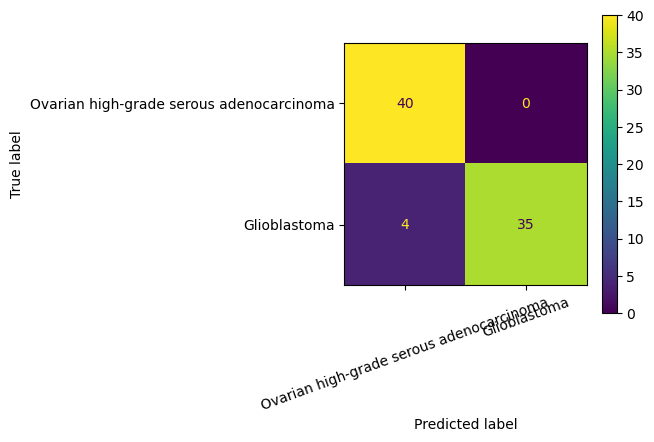

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]],
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
# Fit coefficients from the logistic-regression part of the pipeline.
logreg = clf.named_steps["logisticregression"]

# Turn the coefficient vector into a pandas Series so that each value
# is labeled by its genome-bin feature name.
coefs = pd.Series(logreg.coef_[0], index=feature_cols)

# The bins with the largest positive coefficients support class 1
# (Glioblastoma in this notebook).
top_positive = coefs.sort_values(ascending=False).head(15).rename("coefficient").reset_index()
top_positive = top_positive.rename(columns={"index": "bin_id"})

# The bins with the most negative coefficients support class 0
# (Ovarian high-grade serous adenocarcinoma in this notebook).
top_negative = coefs.sort_values(ascending=True).head(15).rename("coefficient").reset_index()
top_negative = top_negative.rename(columns={"index": "bin_id"})

# Add a small helper column that is easier to read in class.
def format_bin_label(bin_id):
    # Example input: chr13_20000000_30000000
    chrom, start, end = bin_id.replace("chr", "").split("_")
    start_mb = int(start) / 1_000_000
    end_mb = int(end) / 1_000_000
    return f"chr{chrom}:{start_mb:.0f}-{end_mb:.0f} Mb"

top_positive["region"] = top_positive["bin_id"].map(format_bin_label)
top_negative["region"] = top_negative["bin_id"].map(format_bin_label)

print("Bins favoring Glioblastoma")
display(top_positive[["bin_id", "region", "coefficient"]])

print("Bins favoring Ovarian high-grade serous adenocarcinoma")
display(top_negative[["bin_id", "region", "coefficient"]])


Bins favoring Glioblastoma


,bin_id,region,coefficient
0,chr7_10000000_20000000,chr7:10-20 Mb,0.307023
1,chr7_20000000_30000000,chr7:20-30 Mb,0.296866
2,chr4_40000000_50000000,chr4:40-50 Mb,0.279799
3,chr18_60000000_70000000,chr18:60-70 Mb,0.261521
4,chr4_80000000_90000000,chr4:80-90 Mb,0.237993
5,chr7_50000000_60000000,chr7:50-60 Mb,0.236378
6,chr18_50000000_60000000,chr18:50-60 Mb,0.232615
7,chr8_0_10000000,chr8:0-10 Mb,0.228835
8,chr4_50000000_60000000,chr4:50-60 Mb,0.220071
9,chr3_20000000_30000000,chr3:20-30 Mb,0.219368


Bins favoring Ovarian high-grade serous adenocarcinoma


,bin_id,region,coefficient
0,chr8_130000000_140000000,chr8:130-140 Mb,-0.346343
1,chr1_130000000_140000000,chr1:130-140 Mb,-0.337152
2,chr20_60000000_64444167,chr20:60-64 Mb,-0.323382
3,chr1_120000000_130000000,chr1:120-130 Mb,-0.306586
4,chr12_10000000_20000000,chr12:10-20 Mb,-0.303045
5,chr22_30000000_40000000,chr22:30-40 Mb,-0.269249
6,chr4_190000000_190214555,chr4:190-190 Mb,-0.255717
7,chr8_140000000_145138636,chr8:140-145 Mb,-0.255582
8,chr15_80000000_90000000,chr15:80-90 Mb,-0.225992
9,chr20_50000000_60000000,chr20:50-60 Mb,-0.225137


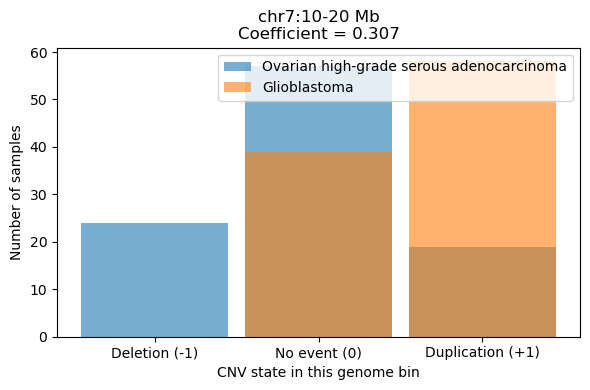

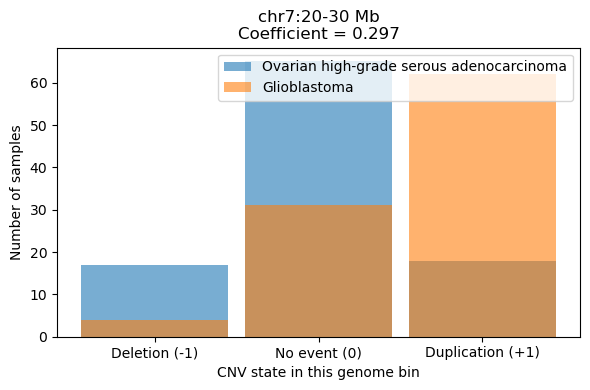

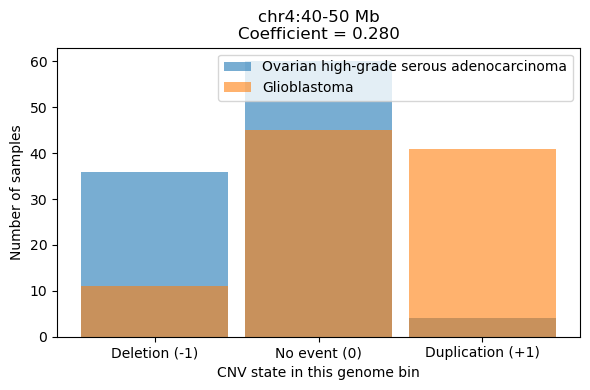

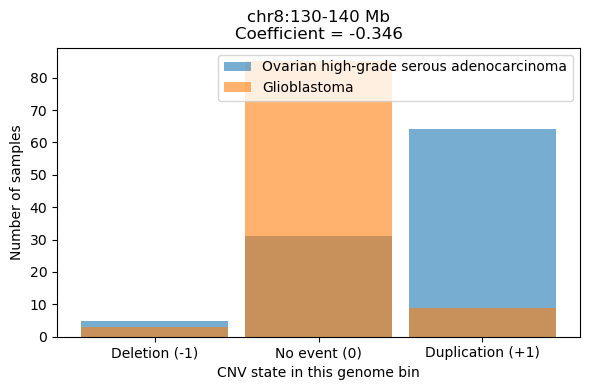

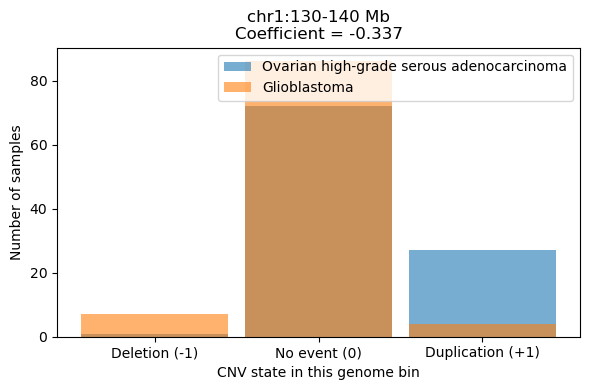

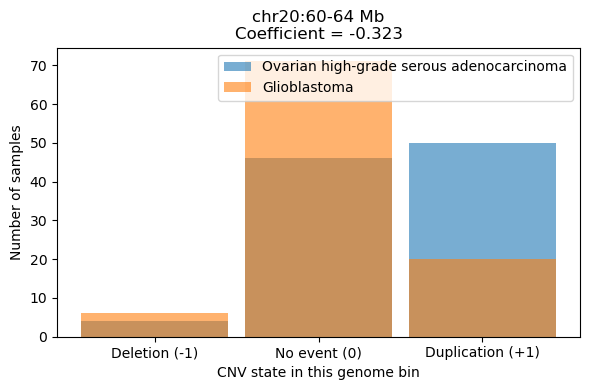

Official Progenetix group-level CNV frequency plots


,group_code,group_label,collationplot_link
0,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,https://progenetix.org/services/collationplots...
1,NCIT:C3058,Glioblastoma,https://progenetix.org/services/collationplots...


In [22]:
# Add readable group labels for plotting.
plot_df = model_df.copy()
plot_df["group_label"] = plot_df["group_code"].map(GROUP_LABELS)

# Take a small set of highly informative bins:
# three bins favoring glioblastoma and three bins favoring ovarian HGSC.
bins_to_plot = (
    top_positive["bin_id"].head(3).tolist() +
    top_negative["bin_id"].head(3).tolist()
)

# Remove duplicates while preserving order.
bins_to_plot = list(dict.fromkeys(bins_to_plot))

for bin_id in bins_to_plot:
    plt.figure(figsize=(6, 4))

    # Plot one histogram per class on the same axes.
    for group_code in [GROUP_1, GROUP_2]:
        values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
        plt.hist(
            values,
            bins=[-1.5, -0.5, 0.5, 1.5],
            alpha=0.6,
            label=GROUP_LABELS[group_code],
            rwidth=0.9,
        )

    coef_value = coefs[bin_id]
    plt.xticks([-1, 0, 1], ["Deletion (-1)", "No event (0)", "Duplication (+1)"])
    plt.xlabel("CNV state in this genome bin")
    plt.ylabel("Number of samples")
    plt.title(f"{format_bin_label(bin_id)}\nCoefficient = {coef_value:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Progenetix links for the two groups used in this notebook.
progenetix_links = pd.DataFrame({
    "group_code": [GROUP_1, GROUP_2],
    "group_label": [GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]],
    "collationplot_link": [
        f"https://progenetix.org/services/collationplots/?filters={GROUP_1}",
        f"https://progenetix.org/services/collationplots/?filters={GROUP_2}",
    ],
})

print("Official Progenetix group-level CNV frequency plots")
display(progenetix_links)
